In [1]:
import math
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader, Dataset, Subset
import yfinance as yf


In [2]:
apple_data = pd.read_excel("/kaggle/input/datasets/qizhaochan/news-info-part2/News_Info_part2.xlsx", sheet_name="Pepsi")
apple_data['date']=pd.to_datetime(apple_data['date']).dt.date

apple_data.dropna(inplace=True)
apple_data

,date,title,content,link,symbols,tags,sentiment
0,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,The stock market has performed well so far thi...,https://finance.yahoo.com/news/steady-dividend...,"['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...",[],"{'polarity': 0.998, 'neg': 0.014, 'neu': 0.869..."
1,2024-05-08,"7-Eleven, Inc. to Release New Limited Edition ...","7-Eleven®, Speedway® and Stripes® customers ca...",https://finance.yahoo.com/news/7-eleven-inc-re...,"['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...",[],"{'polarity': 0.995, 'neg': 0.012, 'neu': 0.885..."
2,2024-05-08,UPS CFO Brian Newman is departing. But the fir...,Good morning. A delivery giant is searching fo...,https://finance.yahoo.com/news/ups-cfo-brian-n...,"['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...",[],"{'polarity': 0.998, 'neg': 0.015, 'neu': 0.874..."
3,2024-05-08,VDC: Strong and Steady Consumer Staples ETF,"Whether it’s Coca-Cola (NYSE:KO), Hershey (NYS...",https://finance.yahoo.com/news/vdc-strong-stea...,"['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...",[],"{'polarity': 0.999, 'neg': 0.032, 'neu': 0.817..."
4,2024-05-08,Steady Dividend Plays: 3 Stocks Promising Reli...,"Johnson &amp; Johnson, PepsiCo, and Southern C...",https://investorplace.com/2024/05/three-stocks...,"['JNJ.US', 'PEP.US']",[],"{'polarity': 0.671, 'neg': 0, 'neu': 0.766, 'p..."
...,...,...,...,...,...,...,...
3642,2018-02-05,Research Report Identifies Franklin Electric C...,"NEW YORK, Feb. 05, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['BDX.US', 'FELE.US', 'FHN.US', 'OTTR.US', 'PE...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.997, 'neg': 0.008, 'neu': 0.934..."
3643,2018-02-01,"PepsiCo, Inc. (Nasdaq: PEP) to Ring The Nasdaq...","ADVISORY, Feb. 01, 2018 (GLOBE NEWSWIRE) --\...",https://www.globenewswire.com/news-release/201...,"['NDAQ.US', 'PEP.US']","['ADVISORY', 'INC', 'NASDAQ', 'NASDAQ:NDAQ']","{'polarity': 0.996, 'neg': 0.004, 'neu': 0.866..."
3644,2017-11-29,Investor Expectations to Drive Momentum within...,"NEW YORK, Nov. 29, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['DAL.US', 'HUM.US', 'NUAN.US', 'PEP.US', 'SYY...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.995, 'neg': 0.009, 'neu': 0.936..."
3645,2017-10-24,Consolidated Research: 2018 Summary Expectatio...,"NEW YORK, Oct. 24, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"['GRPN.US', 'M.US', 'PEP.US', 'RDC.US', 'SLB.U...",['FUNDAMENTAL MARKETS'],"{'polarity': 0.996, 'neg': 0.012, 'neu': 0.926..."


In [3]:
unique_tickers = pd.read_excel("/kaggle/input/datasets/qizhaochan/fixed-node/fixed nodes.xlsx")['Pepsi'].dropna()
unique_tickers = list(unique_tickers)

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

def finbert_sentiment_pipeline(device=-1):
    model_name = "ProsusAI/finbert"

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)

    return pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=device
    )

In [5]:



def classify_news_sentiment(news_df: pd.DataFrame, pipe) -> pd.DataFrame:
    """
    Run FinBERT sentiment on each news text and return the news_df with 'label' and 'score' columns.
    label usually one of: 'positive', 'neutral', 'negative' (model dependent); we will normalize later.
    """
    texts = news_df["title"].tolist()
    # pipe can process batches; to be safe, process in small batches
    batch_size = 16
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        outs = pipe(batch, truncation=True)
        # outs: list of {'label': 'positive', 'score': 0.98} etc.
        for o in outs:
            labels.append(o["label"])
            scores.append(float(o.get("score", 0.0)))
    import copy
    df = news_df.copy().reset_index(drop=True)
    df["label"] = labels
    df["score"] = scores
    return df

In [6]:
from typing import List, Tuple

def aggregate_sentiment_per_company_day(news_df_with_labels: pd.DataFrame, tickers: List[str], date_index: pd.DatetimeIndex):
    """
    For each (date, ticker) compute an aggregated sentiment score.
    Strategy:
      - Map labels to numeric: positive -> +1, neutral -> 0, negative -> -1
      - Use label * score as weighted value, average across news mentioning the ticker (normalized format) on that date.
    Returns:
      sentiment_df: DataFrame indexed by date_index (dates from price_df) with columns tickers (shape T x N)
    """

    def label_to_num(lab):
        if pd.isna(lab):
            return 0.0
        s = str(lab).lower()
        if "pos" in s:
            return 1.0
        elif "neg" in s:
            return -1.0
        else:
            return 0.0

    tmp = news_df_with_labels.copy()
    #tmp["date"] = pd.to_datetime(tmp["date"]).dt.normalize()

    # Ensure mentions are parsed lists
    if isinstance(tmp["mentions"].iloc[0], str):
        tmp["mentions"] = tmp["mentions"].apply(lambda x: eval(x) if isinstance(x, str) else x)

    # Normalize tickers in 'mentions' — e.g. "AAPL.US" -> "AAPL"
    def normalize_ticker(name):
        if not isinstance(name, str):
            return name
        return name.split(".")[0].upper().strip()

    tmp["mentions"] = tmp["mentions"].apply(lambda lst: [normalize_ticker(x) for x in lst])

    # Aggregate sentiment values
    accum = {}
    for _, row in tmp.iterrows():
        d = row["date"]
        numeric = label_to_num(row["label"]) * float(row["score"])
        for t in row["mentions"]:
            if t in tickers:  # only keep known companies
                accum.setdefault((d, t), []).append(numeric)

    # Build sentiment matrix
    rows = []
    for d in date_index:
        row_vals = []
        for t in tickers:
            vals = accum.get((d, t), [])
            row_vals.append(float(np.mean(vals)) if vals else 0.0)
        rows.append(row_vals)

    sentiment_df = pd.DataFrame(rows, index=date_index, columns=tickers).astype(np.float32)
    return sentiment_df


In [7]:
start_date = apple_data["date"].min()
end_date = apple_data["date"].max()

In [8]:
price_df = yf.download(unique_tickers, start=start_date, end=end_date, progress=False)["Close"]

#price_df = price_df[unique_tickers]
price_df = price_df.dropna(how="all").ffill().dropna(axis=1)  # drop tickers with no data
print(f"Price data shape: {price_df.shape}")

news_df = apple_data[['date', 'title', 'symbols']]  # Include symbols for mentions
news_df.rename(columns={'symbols': 'mentions'}, inplace=True)

# run FinBERT sentiment classification (this will download model the first time)
print("Loading FinBERT pipeline (this may take a while for first run)...")
pipe = finbert_sentiment_pipeline()  # cpu; set device=0 for GPU
print("Classifying synthetic news with FinBERT...")
news_labeled = classify_news_sentiment(news_df, pipe)
news_labeled.reset_index(inplace=True, drop=True)  # Reset index to make date a column again
print("Sample labeled news:")
print(news_labeled.head())

/tmp/ipykernel_58/3160259362.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_df = yf.download(unique_tickers, start=start_date, end=end_date, progress=False)["Close"]


Price data shape: (2145, 1694)
Loading FinBERT pipeline (this may take a while for first run)...


/tmp/ipykernel_58/3160259362.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_df.rename(columns={'symbols': 'mentions'}, inplace=True)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifying synthetic news with FinBERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Sample labeled news:
         date                                              title  \
0  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   
1  2024-05-08  7-Eleven, Inc. to Release New Limited Edition ...   
2  2024-05-08  UPS CFO Brian Newman is departing. But the fir...   
3  2024-05-08        VDC: Strong and Steady Consumer Staples ETF   
4  2024-05-08  Steady Dividend Plays: 3 Stocks Promising Reli...   

                                            mentions     label     score  
0  ['JNJ.US', 'PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.H...  positive  0.929564  
1  ['PEP.BE', 'PEP.DU', 'PEP.F', 'PEP.HM', 'PEP.M...   neutral  0.894171  
2  ['HD.MX', 'HD.NEO', 'HD.US', 'HDI.BE', 'HDI.DU...   neutral  0.568551  
3  ['0J4X.LSE', '0P59.LSE', '4I1.BE', '4I1.F', '4...  positive  0.932543  
4                               ['JNJ.US', 'PEP.US']  positive  0.929564  


In [ ]:
# Get all columns
cols = price_df.columns.tolist()

# Remove 'PEP' from list and insert at beginning
cols.remove('PEP')
cols = ['PEP'] + cols

# Reorder DataFrame
price_df = price_df.reindex(columns=cols)
sentiment_df = aggregate_sentiment_per_company_day(news_labeled, list(price_df.columns), date_index = price_df.index.date)
price_df

Ticker,PEP,A,AA,AAL,AAON,AAP,AAPL,AB,ABBV,ABEV,...,YELP,YORW,YUM,YYY,ZBH,ZBRA,ZG,ZION,ZTS,ZUMZ
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-28,74.027527,34.403057,20.216234,43.731594,13.238205,168.531586,26.727406,10.533687,34.329144,3.311998,...,22.070000,19.019567,43.115532,6.129736,86.944046,78.639999,31.139999,21.941807,39.376144,17.219999
2015-10-29,74.070755,34.568100,20.126278,43.731594,13.001697,171.307465,27.009758,10.377360,34.870575,3.298453,...,22.950001,18.506601,42.843754,6.103768,93.162598,77.839996,30.520000,22.016495,39.566921,17.389999
2015-10-30,73.631210,34.623116,20.081308,44.074886,12.740294,172.131561,26.778942,10.317242,38.383419,3.298453,...,22.250000,18.578739,41.898373,6.142724,92.896065,76.900002,30.809999,21.486240,39.076313,17.480000
2015-11-02,73.062012,35.384174,20.621002,44.313286,13.499609,173.823151,27.155416,10.269139,40.852081,3.352637,...,23.799999,18.618811,42.441971,6.175192,95.010399,78.620003,30.870001,21.807375,40.193832,17.870001
2015-11-03,72.716141,35.090755,21.093245,44.437527,14.140665,172.365738,27.466906,10.233069,40.239742,3.501643,...,24.120001,18.346306,42.666496,6.181684,94.521820,78.620003,30.990000,21.635605,42.444881,18.389999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-01,161.286118,136.282684,33.435448,13.580000,93.612328,69.596153,167.618698,27.178984,150.059494,2.147524,...,40.439999,33.987976,129.586472,8.960876,116.971992,309.049988,41.439999,38.855953,153.279465,17.120001
2024-05-02,161.562363,135.132965,35.085258,13.860000,90.064819,71.397278,171.311630,27.318529,149.215118,2.211766,...,40.000000,34.599945,129.337524,8.991514,115.895805,312.709991,39.189999,39.682674,161.721863,17.120001
2024-05-03,162.206940,137.029480,35.895519,13.850000,77.688225,72.721916,181.558884,27.830492,151.980240,2.230121,...,39.990002,34.741169,128.638458,9.083421,119.026550,309.589996,40.070000,40.518692,161.567169,17.180000


### target company only

In [12]:
sentiment_df = sentiment_df[['PEP']]
sentiment_df

,PEP
2015-10-28,0.844525
2015-10-29,0.000000
2015-10-30,0.000000
2015-11-02,0.000000
2015-11-03,0.000000
...,...
2024-05-01,0.214015
2024-05-02,0.812682
2024-05-03,0.000000
2024-05-06,0.000000


In [13]:
price_df = price_df[['PEP']]
price_df

Ticker,PEP
Date,
2015-10-28,74.027527
2015-10-29,74.070755
2015-10-30,73.631210
2015-11-02,73.062012
2015-11-03,72.716141
...,...
2024-05-01,161.286118
2024-05-02,161.562363
2024-05-03,162.206940


In [14]:
import matplotlib.pyplot as plt


def plot_predictions(predictions):

    plt.figure(figsize=(14, 6))

    # True values
    true_values = predictions[
        list(predictions.keys())[0]
    ]["true"]

    plt.plot(
        true_values,
        label="True",
        linewidth=2
    )

    # Model predictions
    for name, data in predictions.items():

        plt.plot(
            data["pred"],
            label=name,
            alpha=0.8
        )

    plt.xlabel("Test Samples")
    plt.ylabel("Normalized Close Price")
    plt.title(
        "Predicted vs True Stock Price "
        "(Target Company)"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_58/344871680.py:383: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/344871680.py:385: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = pd.to_datetime(price_df['date']).dt.tz_localize(None)
/tmp/ipykernel_58/344871680.py:396: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur


Training LSTM...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 0.358753
  New best model! Val Loss: 0.121611
  New best model! Val Loss: 0.112246
Epoch 05/100 | Train Loss: 0.171504 | Val Loss: 0.101685 | Patience: 0/20
  New best model! Val Loss: 0.101685
  New best model! Val Loss: 0.089439
  New best model! Val Loss: 0.083968
  New best model! Val Loss: 0.078512
  New best model! Val Loss: 0.077643
Epoch 10/100 | Train Loss: 0.120838 | Val Loss: 0.076277 | Patience: 0/20
  New best model! Val Loss: 0.076277
  New best model! Val Loss: 0.074957
  New best model! Val Loss: 0.074049
  New best model! Val Loss: 0.071696
Epoch 15/100 | Train Loss: 0.107803 | Val Loss: 0.069821 | Patience: 1/20
  New best model! Val Loss: 0.069821
  New best model! Val Loss: 0.068698
  New best model! Val Loss: 0.067720
  New best model! Val Loss: 0.067120
Epoch 20/100 | Train Loss: 0.099880 | Val Loss: 0.065699 | Patience: 1/20
  New best model! Val Loss: 0.065699
  

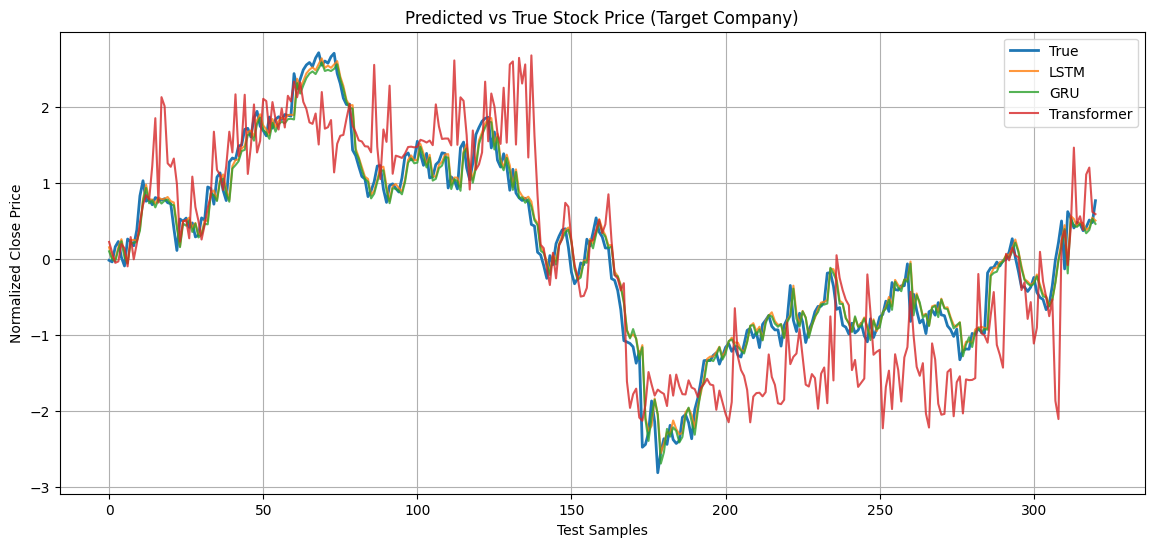


--- Final Comparison ---
LSTM       : MSE 0.048886, MAE 0.161357
GRU        : MSE 0.049424, MAE 0.163693
Transformer: MSE 0.466728, MAE 0.536005


In [ ]:


# =======================================
# 1. Models: LSTM, GRU, and Transformer
# =======================================
''''''
class RNNModel(nn.Module):
    """
    Recurrent Neural Network model (LSTM or GRU) for multi-company target prediction.

    Inputs:
        seq_feats: Tensor of shape (batch, seq_len, N, 3)
    Output:
        out: Tensor of shape (batch,) representing next-day normalized close price
             for target_idx = 0.
    """
    def __init__(
        self,
        in_feats: int,
        hidden_dim: int = 32,
        out_dim: int = 1,
        num_layers: int = 1,
        dropout: float = 0.2,
        model_type: str = "LSTM"
    ):
        super().__init__()
        # in_feats = N * 3
        if model_type == "LSTM":
            self.rnn = nn.LSTM(
                input_size=in_feats,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout 
            )
        else:
            self.rnn = nn.GRU(
                input_size=in_feats,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
        self.fc = nn.Linear(hidden_dim, out_dim)

    def forward(self, seq_feats: torch.Tensor) -> torch.Tensor:
        # seq_feats: (batch, seq_len, N, 3)
        batch, seq_len, N, F = seq_feats.shape

        # Flatten spatial/ticker feature dimensions at each time step:
        # (batch, seq_len, N, 3) -> (batch, seq_len, N * 3)
        x = seq_feats.view(batch, seq_len, N * F)

        # Recurrent pass:
        # out: (batch, seq_len, hidden_dim)
        out, _ = self.rnn(x)

        # Take the last time step hidden state:
        # out[:, -1, :]: (batch, hidden_dim)
        last_hidden = out[:, -1, :]

        # Linear projection to single target output:
        # pred: (batch, 1) -> squeezed to (batch,)
        pred = self.fc(last_hidden).squeeze(-1)

        return pred


class PositionalEncoding(nn.Module):
    """
    Standard Sinusoidal Positional Encoding for Transformer inputs.
    """
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # Shape: (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(
        self,
        in_feats: int,
        hidden_dim: int = 64,
        out_dim: int = 1,
        nhead: int = 1,
        num_layers: int = 1,
        dropout: float = 0.2
    ):
        super().__init__()
        
        self.encoder = nn.Linear(in_feats, hidden_dim)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True,
            activation='relu'  # Standard, matches your simple description
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, out_dim)
    
    def forward(self, seq_feats: torch.Tensor) -> torch.Tensor:
        batch, seq_len, N, F = seq_feats.shape
        
        # Flatten spatial dimensions: (batch, seq_len, N*F)
        x = seq_feats.view(batch, seq_len, N * F)
        
        # Project to hidden dimension
        x = self.encoder(x)
        
        # Add positional encoding
        x = self.pos_encoder(x)
        
        # Transformer encoder
        x = self.transformer(x)
        
        # Take last time step and project
        last_hidden = x[:, -1, :]
        pred = self.fc(last_hidden).squeeze(-1)
        
        return pred


class FinancialDataset(Dataset):
    def __init__(
        self,
        price_df,
        sentiment_df,
        seq_len=5,
        window_size=252,
        vol_window=20,
        target_idx=0
    ):
        super().__init__()
        
        self.seq_len = seq_len
        self.target_idx = target_idx
        self.tickers = list(price_df.columns)
        
        # Convert to numpy
        prices = price_df.values.astype(np.float32)
        sentiments = sentiment_df.values.astype(np.float32)
        T, N = prices.shape
        
        # =============================
        # 1. Compute log returns (matches pseudo-code exactly)
        # =============================
        log_returns = np.zeros((T, N), dtype=np.float32)
        ratio = np.divide(
            prices[1:], prices[:-1],
            out=np.ones_like(prices[1:]),
            where=(prices[:-1] > 0)
        )
        ratio = np.maximum(ratio, 1e-8)
        log_returns[1:] = np.log(ratio)
        
        # =============================
        # 2. Feature calculation (matches pseudo-code)
        # =============================
        norm_prices = np.zeros((T, N), dtype=np.float32)
        annualized_vol = np.zeros((T, N), dtype=np.float32)
        
        for t in range(T):
            # Price normalization (exactly as pseudo-code)
            if t == 0:
                norm_prices[t] = 0.0
            else:
                start_idx = max(0, t - window_size)
                historical_prices = prices[start_idx:t]  # t is exclusive, matches pseudo-code
                mean_t = historical_prices.mean(axis=0)
                std_t = historical_prices.std(axis=0)
                std_t = np.where(std_t < 1e-6, 1.0, std_t)  # Different: uses 1.0 instead of keeping 1e-6
                norm_prices[t] = (prices[t] - mean_t) / std_t
            
            # Volatility (exactly as pseudo-code)
            if t < vol_window:
                annualized_vol[t] = 0.0
            else:
                return_window = log_returns[t - vol_window:t]  # t is exclusive, gets exactly vol_window items
                daily_vol = return_window.std(axis=0)
                annualized_vol[t] = daily_vol * np.sqrt(252)
        
        # =============================
        # 3. Build feature tensor (KEEP ALL T TIMESTEPS to match pseudo-code)
        # =============================
        # Vectorized version, keeping all T timesteps
        self.features = np.stack([norm_prices, sentiments, annualized_vol], axis=2)
        # Shape: (T, N, 3)
        
        # =============================
        # 4. Targets (next-day normalized price)
        # =============================
        # Target for timestep t is norm_prices[t+1]
        # So targets[t] = norm_prices[t+1] for t = 0..T-2
        self.targets = norm_prices[1:T]  # Shape: (T-1, N)
        
        # =============================
        # 5. Valid indices (matches revised pseudo-code: {L, ..., T-2})
        # =============================
        # We need:
        # - Sequence from start_t to end_t (inclusive): length = seq_len
        # - Target at end_t + 1
        # So end_t must satisfy: end_t + 1 < T => end_t <= T-2
        # And end_t >= seq_len - 1 (for sequence length)
        self.valid_indices = list(range(seq_len - 1, T - 1))
        # This gives: seq_len-1, seq_len, ..., T-2
        
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        end_t = self.valid_indices[idx]
        start_t = end_t - self.seq_len + 1
        
        # Get sequence features (all N companies, 3 features)
        seq_feats = torch.tensor(
            self.features[start_t:end_t + 1],  # Inclusive of end_t
            dtype=torch.float32
        )
        
        # Next-day normalized price for target company
        target = torch.tensor(
            self.targets[end_t, self.target_idx],  # This is norm_prices[end_t + 1]
            dtype=torch.float32
        )
        
        return {
            "seq_feats": seq_feats,  # Shape: (seq_len, N, 3)
            "target": target         # Shape: scalar
        }


def collate_fn(batch: list) -> Dict[str, torch.Tensor]:
    """
    Custom collate function to form batches.
    seq_feats shape: (batch, seq_len, N, 3)
    target shape: (batch,)
    """
    return {
        "seq_feats": torch.stack([item["seq_feats"] for item in batch]),
        "target": torch.stack([item["target"] for item in batch])
    }


# =======================================
# 3. Training & Evaluation Logic
# =======================================

def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device
) -> float:
    model.train()
    total_loss = 0.0

    for batch in loader:
        # x shape: (batch, seq_len, N, 3)
        # y shape: (batch,)
        x = batch["seq_feats"].to(device)
        y = batch["target"].to(device)

        optimizer.zero_grad()

        # pred shape: (batch,)
        pred = model(x)

        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch in loader:

            x = batch["seq_feats"].to(device)
            y = batch["target"].to(device)

            pred = model(x)

            loss = criterion(pred, y)
            total_loss += loss.item()

            all_preds.append(pred.cpu().numpy())
            all_trues.append(y.cpu().numpy())

    preds_flat = np.concatenate(all_preds, axis=0)
    trues_flat = np.concatenate(all_trues, axis=0)

    # Remove NaN if necessary
    mask = ~(np.isnan(preds_flat) | np.isnan(trues_flat))
    preds_flat = preds_flat[mask]
    trues_flat = trues_flat[mask]

    metrics = {
        "MSE": float(mean_squared_error(trues_flat, preds_flat)),
        "MAE": float(mean_absolute_error(trues_flat, preds_flat))
    }

    return (
        total_loss / len(loader),
        metrics,
        preds_flat,
        trues_flat
    )


# =======================================
# 4. Main Execution Block
# =======================================

def run_experiment(sentiment_df: pd.DataFrame, price_df: pd.DataFrame = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tickers = sentiment_df.columns.tolist()
    target_idx = 0

    price_df['date'] = price_df.index
    sentiment_df['date'] = sentiment_df.index
    price_df['date'] = pd.to_datetime(price_df['date']).dt.tz_localize(None)
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.tz_localize(None)

    sentiment_df = sentiment_df.add_suffix('_sent')
    sentiment_df.rename(columns={'date_sent': 'date'}, inplace=True)

    # Merge date alignments
    merged = pd.merge(price_df, sentiment_df, on="date", how="left")
    merged = merged.ffill().bfill()

    sentiment_df = sentiment_df.drop(columns=['date'])
    price_df = price_df.drop(columns=['date'])

    # Instantiate dataset targeting target_idx = 0
    dataset = FinancialDataset(
        price_df=price_df,
        sentiment_df=sentiment_df,
        seq_len=5,
        target_idx=target_idx
    )

    # Sequential split (70% Train, 15% Val, 15% Test)
    n = len(dataset)
    train_end, val_end = int(n * 0.7), int(n * 0.85)

    train_loader = DataLoader(
        Subset(dataset, range(0, train_end)),
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        Subset(dataset, range(train_end, val_end)),
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        Subset(dataset, range(val_end, n)),
        batch_size=32,
        shuffle=False,
        collate_fn=collate_fn
    )

    # Calculate flattened feature input size: N * 3
    num_companies = dataset.features.shape[1]
    num_features_per_company = dataset.features.shape[2]
    input_dim = num_companies * num_features_per_company

    models = {
        "LSTM": RNNModel(in_feats=input_dim, model_type="LSTM"),
        "GRU": RNNModel(in_feats=input_dim, model_type="GRU"),
        "Transformer": TransformerModel(in_feats=input_dim)
    }

    results = {}
    predictions = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.to(device)
        
        # Different learning rates for different models
        if name == "Transformer":
            optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Lower LR for Transformer
        else:
            optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        criterion = nn.MSELoss()
        
        # ==========================================
        # EARLY STOPPING SETUP
        # ==========================================
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        patience = 20  # Number of epochs to wait before stopping
        max_epochs = 100  # Maximum number of epochs
        
        print(f"Starting training with early stopping (patience={patience})...")
        
        for epoch in range(1, max_epochs + 1):
            # Training
            train_loss = train_epoch(
                model,
                train_loader,
                optimizer,
                criterion,
                device
            )
            
            # Validation
            val_loss, _, _, _ = evaluate(
                model,
                val_loader,
                criterion,
                device
            )
            
            # Print progress every 5 epochs
            if epoch % 5 == 0:
                print(
                    f"Epoch {epoch:02d}/{max_epochs} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"Patience: {patience_counter}/{patience}"
                )
            
            # ==========================================
            # EARLY STOPPING CHECK
            # ==========================================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # Save the best model state
                best_model_state = model.state_dict().copy()
                print(f"  New best model! Val Loss: {best_val_loss:.6f}")
            else:
                patience_counter += 1
                
            # Stop training if patience is exceeded
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                print(f"Best validation loss: {best_val_loss:.6f}")
                break
        
        # ==========================================
        # LOAD BEST MODEL FOR TESTING
        # ==========================================
        if best_model_state is not None:
            print("Loading best model for testing...")
            model.load_state_dict(best_model_state)
        else:
            print("Warning: No best model found, using final model.")
        
        # Test the best model
        _, metrics, preds, trues = evaluate(
            model,
            test_loader,
            criterion,
            device
        )
        
        results[name] = metrics
        predictions[name] = {
            "pred": preds,
            "true": trues
        }
        
        print(
            f"{name} Test Results "
            f"(Target Company Index {target_idx}): {metrics}"
        )

    # Plot after all models are done
    plot_predictions(predictions)

    print("\n--- Final Comparison ---")
    for name, m in results.items():
        print(f"{name:11s}: MSE {m['MSE']:.6f}, MAE {m['MAE']:.6f}")
    
    return results, predictions
    


if __name__ == "__main__":
    tickers = sentiment_df.columns.tolist()
    dates = pd.date_range(start=apple_data['date'].min(), end=apple_data['date'].max())


    run_experiment(sentiment_df, price_df)


--- Run 1/5 ---


/tmp/ipykernel_58/3895887188.py:512: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/3895887188.py:513: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = sentiment_df.index
/tmp/ipykernel_58/3895887188.py:514: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u


Training LSTM...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 0.629475
  New best model! Val Loss: 0.133509
  New best model! Val Loss: 0.114541
Epoch 05/100 | Train Loss: 0.187898 | Val Loss: 0.101818 | Patience: 1/20
  New best model! Val Loss: 0.101818
  New best model! Val Loss: 0.092578
  New best model! Val Loss: 0.084741
  New best model! Val Loss: 0.080754
  New best model! Val Loss: 0.077766
Epoch 10/100 | Train Loss: 0.120347 | Val Loss: 0.076740 | Patience: 0/20
  New best model! Val Loss: 0.076740
  New best model! Val Loss: 0.075519
  New best model! Val Loss: 0.074844
  New best model! Val Loss: 0.071976
  New best model! Val Loss: 0.070642
Epoch 15/100 | Train Loss: 0.109046 | Val Loss: 0.079007 | Patience: 0/20
  New best model! Val Loss: 0.068892
  New best model! Val Loss: 0.068463
  New best model! Val Loss: 0.066906
Epoch 20/100 | Train Loss: 0.099489 | Val Loss: 0.065424 | Patience: 0/20
  New best model! Val Loss: 0.065424
  

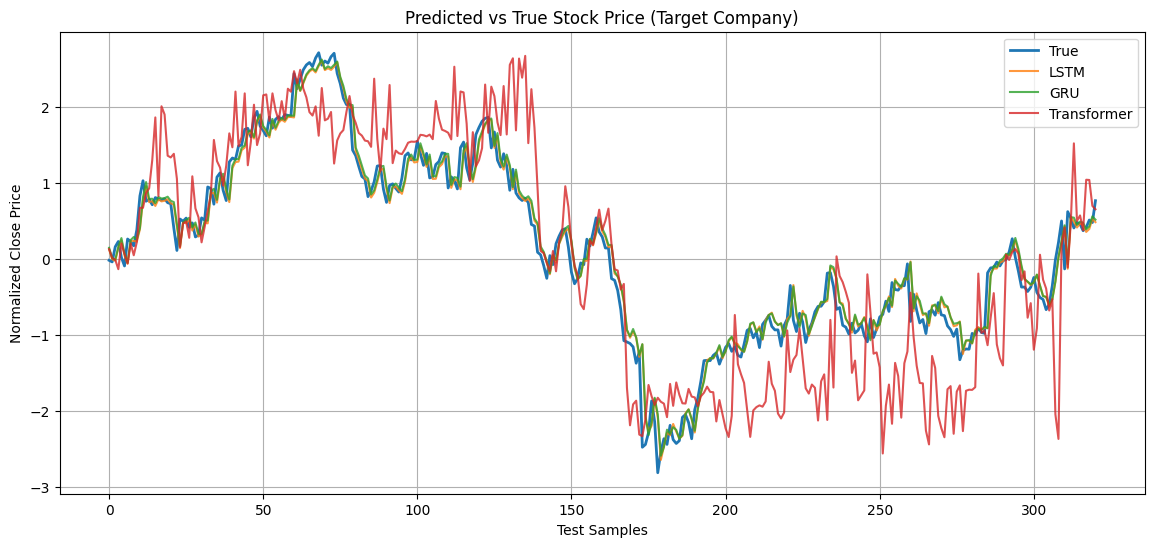


--- Final Comparison ---
LSTM       : MSE 0.049340, MAE 0.162680
GRU        : MSE 0.049441, MAE 0.162963
Transformer: MSE 0.532768, MAE 0.574080

--- Run 2/5 ---


/tmp/ipykernel_58/3895887188.py:512: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/3895887188.py:513: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = sentiment_df.index
/tmp/ipykernel_58/3895887188.py:514: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u


Training LSTM...
Starting training with early stopping (patience=20)...
  New best model! Val Loss: 0.628026
  New best model! Val Loss: 0.128821
  New best model! Val Loss: 0.122507
  New best model! Val Loss: 0.116857
Epoch 05/100 | Train Loss: 0.180046 | Val Loss: 0.104224 | Patience: 0/20
  New best model! Val Loss: 0.104224
  New best model! Val Loss: 0.094199
  New best model! Val Loss: 0.086385
  New best model! Val Loss: 0.080801
  New best model! Val Loss: 0.077786
Epoch 10/100 | Train Loss: 0.117990 | Val Loss: 0.076205 | Patience: 0/20
  New best model! Val Loss: 0.076205
  New best model! Val Loss: 0.074057
  New best model! Val Loss: 0.073621
  New best model! Val Loss: 0.073445
  New best model! Val Loss: 0.070313
Epoch 15/100 | Train Loss: 0.104830 | Val Loss: 0.071621 | Patience: 0/20
  New best model! Val Loss: 0.069191
  New best model! Val Loss: 0.067080
  New best model! Val Loss: 0.066577
Epoch 20/100 | Train Loss: 0.097990 | Val Loss: 0.072662 | Patience: 1/20
  

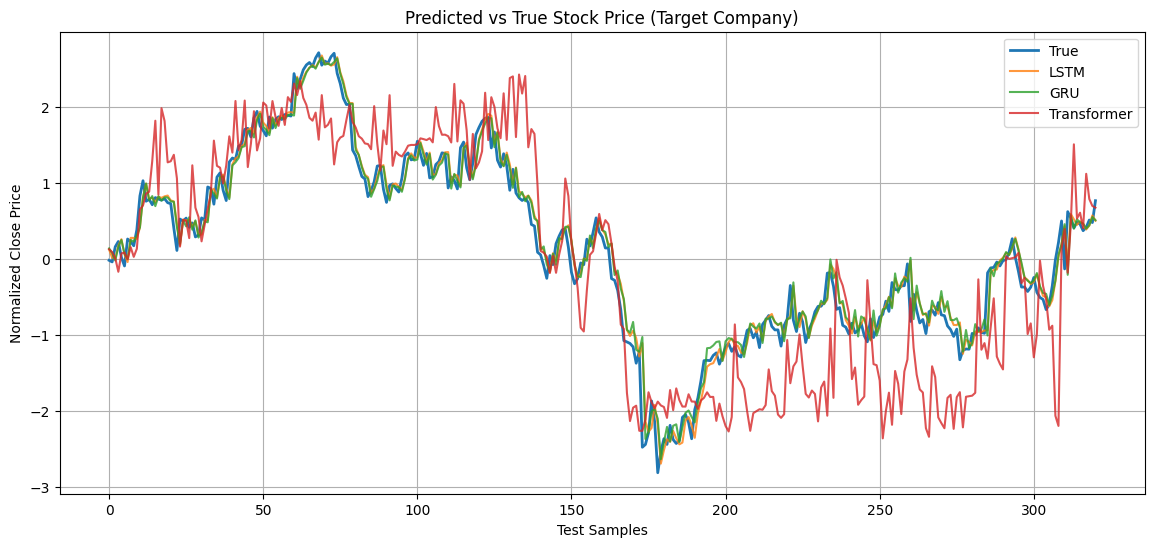


--- Final Comparison ---
LSTM       : MSE 0.049584, MAE 0.163884
GRU        : MSE 0.052473, MAE 0.166301
Transformer: MSE 0.522796, MAE 0.576123

--- Run 3/5 ---

Training LSTM...
Starting training with early stopping (patience=20)...


/tmp/ipykernel_58/3895887188.py:512: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/3895887188.py:513: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = sentiment_df.index
/tmp/ipykernel_58/3895887188.py:514: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

  New best model! Val Loss: 0.458446
  New best model! Val Loss: 0.133029
  New best model! Val Loss: 0.120130
  New best model! Val Loss: 0.117211
Epoch 05/100 | Train Loss: 0.204934 | Val Loss: 0.111005 | Patience: 0/20
  New best model! Val Loss: 0.111005
  New best model! Val Loss: 0.099527
  New best model! Val Loss: 0.096489
  New best model! Val Loss: 0.085276
  New best model! Val Loss: 0.078398
Epoch 10/100 | Train Loss: 0.120073 | Val Loss: 0.075530 | Patience: 0/20
  New best model! Val Loss: 0.075530
  New best model! Val Loss: 0.074121
  New best model! Val Loss: 0.070492
  New best model! Val Loss: 0.069126
Epoch 15/100 | Train Loss: 0.104868 | Val Loss: 0.068195 | Patience: 0/20
  New best model! Val Loss: 0.068195
  New best model! Val Loss: 0.066851
  New best model! Val Loss: 0.066493
  New best model! Val Loss: 0.066456
  New best model! Val Loss: 0.064607
Epoch 20/100 | Train Loss: 0.097632 | Val Loss: 0.064016 | Patience: 0/20
  New best model! Val Loss: 0.064016
 

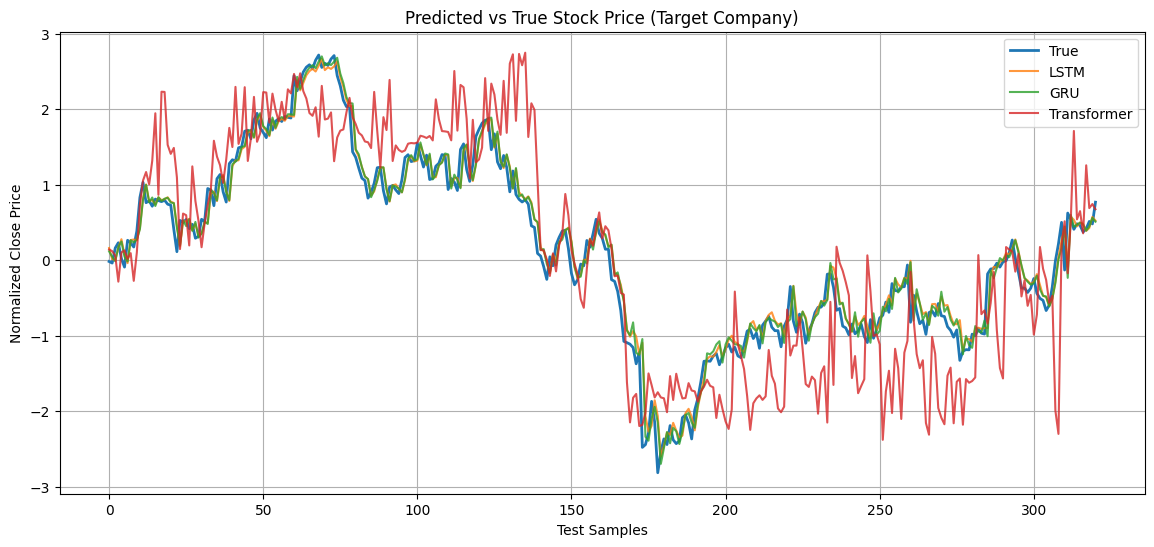


--- Final Comparison ---
LSTM       : MSE 0.050873, MAE 0.165662
GRU        : MSE 0.051810, MAE 0.166074
Transformer: MSE 0.515028, MAE 0.563517

--- Run 4/5 ---

Training LSTM...
Starting training with early stopping (patience=20)...


/tmp/ipykernel_58/3895887188.py:512: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/3895887188.py:513: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = sentiment_df.index
/tmp/ipykernel_58/3895887188.py:514: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

  New best model! Val Loss: 0.603877
  New best model! Val Loss: 0.130322
  New best model! Val Loss: 0.118664
  New best model! Val Loss: 0.116830
Epoch 05/100 | Train Loss: 0.188311 | Val Loss: 0.104937 | Patience: 0/20
  New best model! Val Loss: 0.104937
  New best model! Val Loss: 0.094168
  New best model! Val Loss: 0.090906
  New best model! Val Loss: 0.083201
  New best model! Val Loss: 0.080277
Epoch 10/100 | Train Loss: 0.121815 | Val Loss: 0.078033 | Patience: 0/20
  New best model! Val Loss: 0.078033
  New best model! Val Loss: 0.077319
  New best model! Val Loss: 0.076342
  New best model! Val Loss: 0.073597
Epoch 15/100 | Train Loss: 0.109921 | Val Loss: 0.072355 | Patience: 1/20
  New best model! Val Loss: 0.072355
  New best model! Val Loss: 0.070119
  New best model! Val Loss: 0.068794
Epoch 20/100 | Train Loss: 0.101158 | Val Loss: 0.066257 | Patience: 1/20
  New best model! Val Loss: 0.066257
  New best model! Val Loss: 0.065480
  New best model! Val Loss: 0.064923
E

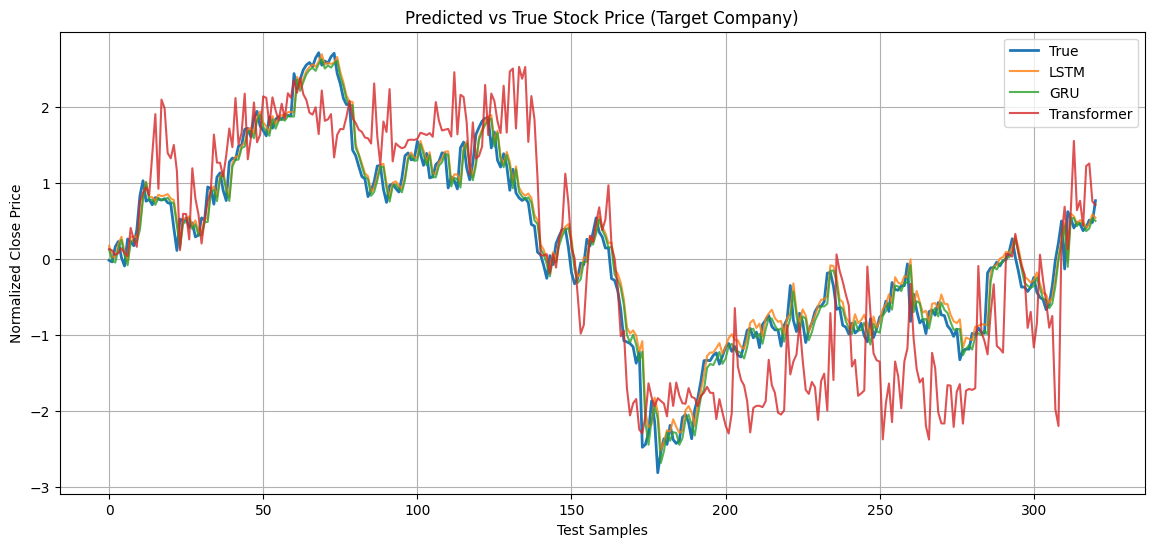


--- Final Comparison ---
LSTM       : MSE 0.052683, MAE 0.170247
GRU        : MSE 0.047522, MAE 0.160317
Transformer: MSE 0.517457, MAE 0.575466

--- Run 5/5 ---

Training LSTM...
Starting training with early stopping (patience=20)...


/tmp/ipykernel_58/3895887188.py:512: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_df['date'] = price_df.index
/tmp/ipykernel_58/3895887188.py:513: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df['date'] = sentiment_df.index
/tmp/ipykernel_58/3895887188.py:514: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/u

  New best model! Val Loss: 0.460989
  New best model! Val Loss: 0.132616
  New best model! Val Loss: 0.120897
  New best model! Val Loss: 0.118412
Epoch 05/100 | Train Loss: 0.180249 | Val Loss: 0.104955 | Patience: 0/20
  New best model! Val Loss: 0.104955
  New best model! Val Loss: 0.098116
  New best model! Val Loss: 0.088768
  New best model! Val Loss: 0.083394
  New best model! Val Loss: 0.078410
Epoch 10/100 | Train Loss: 0.119936 | Val Loss: 0.077224 | Patience: 0/20
  New best model! Val Loss: 0.077224
  New best model! Val Loss: 0.074399
  New best model! Val Loss: 0.072599
  New best model! Val Loss: 0.071059
  New best model! Val Loss: 0.069960
Epoch 15/100 | Train Loss: 0.103805 | Val Loss: 0.068366 | Patience: 0/20
  New best model! Val Loss: 0.068366
  New best model! Val Loss: 0.067230
  New best model! Val Loss: 0.066023
Epoch 20/100 | Train Loss: 0.099165 | Val Loss: 0.064206 | Patience: 1/20
  New best model! Val Loss: 0.064206
  New best model! Val Loss: 0.064151
E

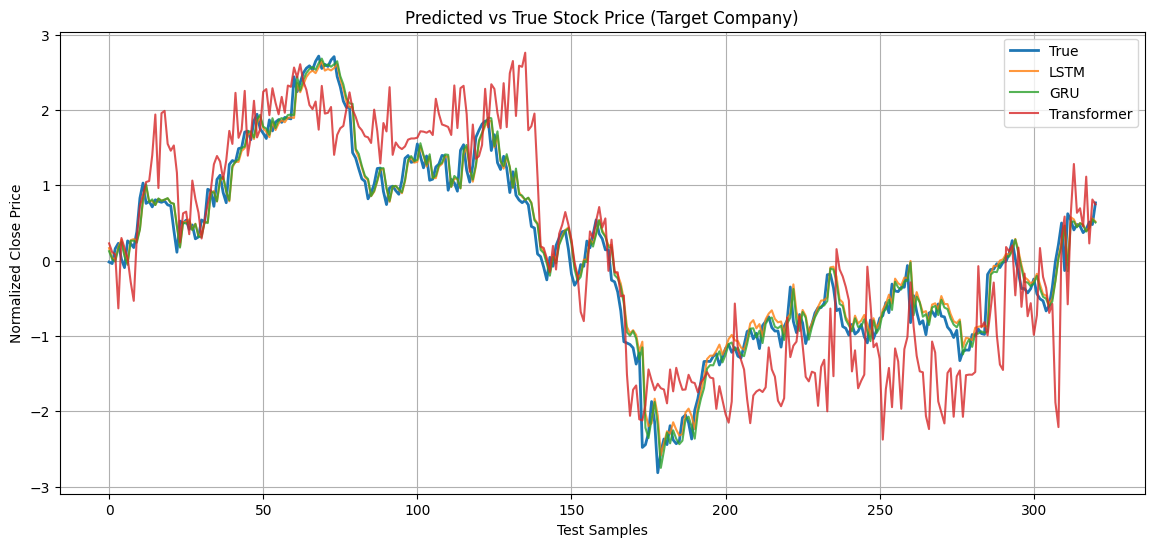


--- Final Comparison ---
LSTM       : MSE 0.052424, MAE 0.169932
GRU        : MSE 0.049033, MAE 0.162126
Transformer: MSE 0.482238, MAE 0.559351

LSTM:
  MSE: 0.050981 ± 0.001388
  MAE: 0.166481 ± 0.003097

GRU:
  MSE: 0.050056 ± 0.001831
  MAE: 0.163556 ± 0.002313

Transformer:
  MSE: 0.514057 ± 0.017038
  MAE: 0.569707 ± 0.006914


{'LSTM': {'MSE_mean': np.float64(0.05098104774951935),
  'MSE_std': np.float64(0.001388236521539609),
  'MAE_mean': np.float64(0.16648114323616028),
  'MAE_std': np.float64(0.0030966239625737934)},
 'GRU': {'MSE_mean': np.float64(0.05005583092570305),
  'MSE_std': np.float64(0.001831185988810696),
  'MAE_mean': np.float64(0.16355625689029693),
  'MAE_std': np.float64(0.002313449417501669)},
 'Transformer': {'MSE_mean': np.float64(0.5140574514865875),
  'MSE_std': np.float64(0.017037837332508476),
  'MAE_mean': np.float64(0.5697072386741638),
  'MAE_std': np.float64(0.006913870794820239)}}

In [105]:
def run_experiment_simple_multiple_runs(
    sentiment_df: pd.DataFrame, 
    price_df: pd.DataFrame = None,
    n_runs: int = 5
) -> Dict:

    
    all_results = {}
    
    for run in range(n_runs):
        print(f"\n--- Run {run+1}/{n_runs} ---")
        
        # Run your existing experiment function
        results, predictions = run_experiment(sentiment_df, price_df)
        
        # Store results
        for name, metrics in results.items():
            if name not in all_results:
                all_results[name] = {"MSE": [], "MAE": []}
            all_results[name]["MSE"].append(metrics["MSE"])
            all_results[name]["MAE"].append(metrics["MAE"])
    
    # Compute statistics
    summary = {}
    for name in all_results:
        mse_values = np.array(all_results[name]["MSE"])
        mae_values = np.array(all_results[name]["MAE"])
        
        summary[name] = {
            "MSE_mean": np.mean(mse_values),
            "MSE_std": np.std(mse_values),
            "MAE_mean": np.mean(mae_values),
            "MAE_std": np.std(mae_values)
        }
        
        print(f"\n{name}:")
        print(f"  MSE: {summary[name]['MSE_mean']:.6f} ± {summary[name]['MSE_std']:.6f}")
        print(f"  MAE: {summary[name]['MAE_mean']:.6f} ± {summary[name]['MAE_std']:.6f}")
    
    return summary

# Usage
summary = run_experiment_simple_multiple_runs(sentiment_df, price_df, n_runs=5)
summary